# M8_AG1_Detección de Crímenes
#### Autore: Jorge Leodeg Ramirez y Leandro Gutierrez
#### Este documento intenta dar respuesta a la actividad grupal 1 propuesta en el Modulo **Gestión de proyectos**. En él se describirán cada uno de los enunciados postulados y los resultados obtenidos.
#### Febrero 8, 2025

## Enunciado
El Equipo de Ciencia de Datos de IL3 ha sido invitado a una reunión de urgencia sobre los últimos acontecimientos.

Los crímenes han crecido tanto que los alcaldes de los estados más influyentes de Estados Unidos han pedido ayuda a los expertos de Ciencia de Datos de IL3.

Los alcaldes quieren saber:

- Los motivos de los crímenes y si tienen algo que ver con la edad, la raza y el área.
- Sobre todo, piden a los expertos padawan que predigan, a base de un modelo de regresión no tan costoso, cómo poder anticiparse al crimen.

En esta fase se mantendrá la base de datos y el flujo de datos en una estructura simple.

La base de datos en sí será muy plana y la transferencia de datos se ejecutará a través de un archivo de texto que los alcaldes nos facilitarán.

En una versión más lista para la producción, guardaríamos las predicciones nuevamente en la base de datos y las extraeríamos de esa base de datos al panel de informes.

Para este ejemplo, no estamos tratando de diseñar todo a la perfección, sino que, simplemente, entendemos los conceptos básicos para realizar predicciones de series de datos de crímenes por edad, región, razas, etc.

- Limpiar y visualizar los datos.
- Pensar en usar la matriz de correlación.
- Modelar el problema.
- Pensar en hacer la Reducción de características basándose en la matriz de correlación.
- Usar el p-value para validar el modelo.
- Visualizar y explorar muy bien las características de los datos.
- Analizar los residuos.
- Usar Ridge regression con 5-fold cross-validation y gridsearch:
  - Pintar la graficas Coeficientes de ridge en función de la regularización.
  - Encontrar los mejores parámetros para la puntuación alfa y MSE con la visualización.
  - Usar la Regresión lineal ponderada (Weighted Linear regression) y resaltar las métricas de validación de modelo (R-cuadrado, etc.).
- Estudiar el modelo XG boost.



# Solución
## Carga de datos

In [51]:
# importamos las librerias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# definimos el path donde buscar los datos
path = '../datos/crimedata.csv'

# creamos dataframe
df_org = pd.read_csv(path, sep=',', encoding='latin-1', decimal='.', na_values='?')

Previsualizamos los datos

In [52]:
df_org

,communityname,state,countyCode,communityCode,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,burglaries,burglPerPop,larcenies,larcPerPop,autoTheft,autoTheftPerPop,arsons,arsonsPerPop,ViolentCrimesPerPop,nonViolPerPop
0,BerkeleyHeightstownship,NJ,39.0,5320.0,1,11980,3.10,1.37,91.78,6.50,...,14.0,114.85,138.0,1132.08,16.0,131.26,2.0,16.41,41.02,1394.59
1,Marpletownship,PA,45.0,47616.0,1,23123,2.82,0.80,95.57,3.44,...,57.0,242.37,376.0,1598.78,26.0,110.55,1.0,4.25,127.56,1955.95
2,Tigardcity,OR,NaN,NaN,1,29344,2.43,0.74,94.33,3.43,...,274.0,758.14,1797.0,4972.19,136.0,376.30,22.0,60.87,218.59,6167.51
3,Gloversvillecity,NY,35.0,29443.0,1,16656,2.40,1.70,97.35,0.50,...,225.0,1301.78,716.0,4142.56,47.0,271.93,NaN,NaN,306.64,NaN
4,Bemidjicity,MN,7.0,5068.0,1,11245,2.76,0.53,89.16,1.17,...,91.0,728.93,1060.0,8490.87,91.0,728.93,5.0,40.05,NaN,9988.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2210,Mercedcity,CA,NaN,NaN,10,56216,3.07,6.87,61.68,15.23,...,1376.0,2268.72,2563.0,4225.82,489.0,806.25,34.0,56.06,545.75,7356.84
2211,Pinevillecity,LA,NaN,NaN,10,12251,2.68,21.18,76.65,1.52,...,104.0,860.43,574.0,4748.90,24.0,198.56,2.0,16.55,124.10,5824.44
2212,Yucaipacity,CA,NaN,NaN,10,32824,2.46,0.52,92.62,0.98,...,628.0,1709.26,895.0,2435.97,179.0,487.19,8.0,21.77,353.83,4654.20
2213,Beevillecity,TX,NaN,NaN,10,13547,2.89,3.37,69.91,0.90,...,192.0,1508.01,474.0,3722.90,13.0,102.10,1.0,7.85,691.17,5340.87


In [53]:
print(df_org.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2215 entries, 0 to 2214
Columns: 147 entries, communityname to nonViolPerPop
dtypes: float64(116), int64(29), object(2)
memory usage: 2.5+ MB
None


## Sanitización de los datos

Vemos la estructura básica de la tabla

In [54]:
df_org.shape

(2215, 147)

Contamos con una tabla de 2215 observaciones y 147 columnas o dimensiones.

In [55]:
df_org.describe()

,countyCode,communityCode,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,...,burglaries,burglPerPop,larcenies,larcPerPop,autoTheft,autoTheftPerPop,arsons,arsonsPerPop,ViolentCrimesPerPop,nonViolPerPop
count,994.000000,991.000000,2215.000000,2.215000e+03,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,...,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2124.000000,2124.000000,1994.000000,2118.000000
mean,65.587525,45209.251261,5.494357,5.311798e+04,2.707327,9.335102,83.979819,2.670203,7.950176,14.445837,...,761.236890,1033.430203,2137.629295,3372.979150,516.692586,473.965628,30.907721,32.153682,589.078922,4908.241804
std,117.831399,25425.861573,2.872924,2.046203e+05,0.334120,14.247156,16.419080,4.473843,14.589832,4.518623,...,3111.702756,763.354442,7600.573464,1901.316145,3258.164244,504.666026,180.125248,39.240900,614.784518,2739.708901
min,1.000000,70.000000,1.000000,1.000500e+04,1.600000,0.000000,2.680000,0.030000,0.120000,4.580000,...,2.000000,16.920000,10.000000,77.860000,1.000000,6.550000,0.000000,0.000000,0.000000,116.790000
25%,11.000000,22887.000000,3.000000,1.436600e+04,2.500000,0.860000,76.320000,0.620000,0.930000,12.250000,...,95.000000,511.690000,392.000000,2040.080000,30.000000,156.952500,1.000000,7.670000,161.700000,2918.070000
50%,27.000000,46925.000000,5.000000,2.279200e+04,2.660000,2.870000,90.350000,1.230000,2.180000,13.620000,...,205.000000,822.715000,747.000000,3079.510000,75.000000,302.355000,5.000000,21.080000,374.060000,4425.450000
75%,80.500000,65805.000000,8.000000,4.302400e+04,2.850000,11.145000,96.225000,2.670000,7.810000,15.360000,...,508.000000,1350.232500,1675.000000,4335.410000,232.500000,589.775000,16.000000,42.852500,794.400000,6229.280000
max,840.000000,94597.000000,10.000000,7.322564e+06,5.280000,96.670000,99.630000,57.460000,95.290000,54.400000,...,99207.000000,11881.020000,235132.000000,25910.550000,112464.000000,4968.590000,5119.000000,436.370000,4877.060000,27119.760000


Veamos cuantas columnas no tienen valores nulos (`NA`)

In [56]:
# conteo de columnas sin valores nulos
df_org.isna().any()[df_org.isna().any() == False].count()

106

Son 106 columnas que no tienen ningun valor nulo.

Ahora veamos cuantas columnas tienen alguno de sus valores nulos (`NA`)

In [57]:
# conteo de algun valor nulo
df_org.isna().any()[df_org.isna().any() == True].count()

41

Vemos que 41 columnas tienen al menos uno de sos registros nulos. A continuación determinaremos que hacer con ellos, basandonos en la cantidad de datos nulos que contenga cada columna.

Definimos descartar columnas que tengan mas del 10% de sus valores nulos por considerarlas despreciables para el análisis.

In [58]:
# encontramos los porcentajes de nulos de cada columna
porcentaje_nulos = df_org.isnull().mean() * 100

In [59]:
# separamos las columnas que no cumplen el criterio
null_cols = porcentaje_nulos[porcentaje_nulos > 10].index

Podemos ver que existen 24 columnas que poseen mas del 10% de sus valores nulos.

Procedemos a eliminar estas columnas.

In [60]:
# quitamos columnas que no cumplen los criterios
df = df_org.drop(columns=null_cols)

Se define rellenar los valores faltantes remanentes con 0 para denotar la ausencia de valores

In [61]:
df = df.fillna(0)

In [62]:
# visualizamos el dataframe
df

,communityname,state,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,...,burglaries,burglPerPop,larcenies,larcPerPop,autoTheft,autoTheftPerPop,arsons,arsonsPerPop,ViolentCrimesPerPop,nonViolPerPop
0,BerkeleyHeightstownship,NJ,1,11980,3.10,1.37,91.78,6.50,1.88,12.47,...,14.0,114.85,138.0,1132.08,16.0,131.26,2.0,16.41,41.02,1394.59
1,Marpletownship,PA,1,23123,2.82,0.80,95.57,3.44,0.85,11.01,...,57.0,242.37,376.0,1598.78,26.0,110.55,1.0,4.25,127.56,1955.95
2,Tigardcity,OR,1,29344,2.43,0.74,94.33,3.43,2.35,11.36,...,274.0,758.14,1797.0,4972.19,136.0,376.30,22.0,60.87,218.59,6167.51
3,Gloversvillecity,NY,1,16656,2.40,1.70,97.35,0.50,0.70,12.55,...,225.0,1301.78,716.0,4142.56,47.0,271.93,0.0,0.00,306.64,0.00
4,Bemidjicity,MN,1,11245,2.76,0.53,89.16,1.17,0.52,24.46,...,91.0,728.93,1060.0,8490.87,91.0,728.93,5.0,40.05,0.00,9988.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2210,Mercedcity,CA,10,56216,3.07,6.87,61.68,15.23,29.86,15.46,...,1376.0,2268.72,2563.0,4225.82,489.0,806.25,34.0,56.06,545.75,7356.84
2211,Pinevillecity,LA,10,12251,2.68,21.18,76.65,1.52,1.29,17.36,...,104.0,860.43,574.0,4748.90,24.0,198.56,2.0,16.55,124.10,5824.44
2212,Yucaipacity,CA,10,32824,2.46,0.52,92.62,0.98,11.00,11.81,...,628.0,1709.26,895.0,2435.97,179.0,487.19,8.0,21.77,353.83,4654.20
2213,Beevillecity,TX,10,13547,2.89,3.37,69.91,0.90,62.11,17.16,...,192.0,1508.01,474.0,3722.90,13.0,102.10,1.0,7.85,691.17,5340.87


Veamos las variables numéricas con las que contamos

In [63]:
# vemos variables numéricas
df.select_dtypes(include=['float64', 'int']).describe()

,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,...,burglaries,burglPerPop,larcenies,larcPerPop,autoTheft,autoTheftPerPop,arsons,arsonsPerPop,ViolentCrimesPerPop,nonViolPerPop
count,2215.000000,2.215000e+03,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,...,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000
mean,5.494357,5.311798e+04,2.707327,9.335102,83.979819,2.670203,7.950176,14.445837,27.644840,13.975142,...,760.205869,1032.030524,2134.734086,3368.410781,515.992777,473.323688,29.637923,30.832695,530.304005,4693.298483
std,2.872924,2.046203e+05,0.334120,14.247156,16.419080,4.473843,14.589832,4.518623,6.181517,5.970747,...,3109.719923,763.783731,7595.829308,1904.074526,3256.011544,504.625281,176.491345,38.952603,609.438217,2861.188528
min,1.000000,1.000500e+04,1.600000,0.000000,2.680000,0.030000,0.120000,4.580000,9.380000,4.640000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,1.436600e+04,2.500000,0.860000,76.320000,0.620000,0.930000,12.250000,24.415000,11.320000,...,94.500000,510.070000,391.500000,2035.600000,30.000000,156.550000,1.000000,6.460000,113.130000,2725.990000
50%,5.000000,2.279200e+04,2.660000,2.870000,90.350000,1.230000,2.180000,13.620000,26.780000,12.540000,...,205.000000,821.660000,745.000000,3077.530000,75.000000,301.550000,5.000000,19.750000,316.550000,4277.310000
75%,8.000000,4.302400e+04,2.850000,11.145000,96.225000,2.670000,7.810000,15.360000,29.205000,14.345000,...,507.500000,1348.670000,1673.000000,4334.675000,231.500000,589.225000,15.000000,41.435000,722.000000,6100.870000
max,10.000000,7.322564e+06,5.280000,96.670000,99.630000,57.460000,95.290000,54.400000,70.510000,63.620000,...,99207.000000,11881.020000,235132.000000,25910.550000,112464.000000,4968.590000,5119.000000,436.370000,4877.060000,27119.760000


Vemos que 121 de las 123 columnas que conforman el dataset son de tipo numerico.

Veamos ahora las variables cuantitativas

In [64]:
# vemos variables cualitativas
df.select_dtypes(include=['object']).describe()

,communityname,state
count,2215,2215
unique,2018,48
top,Auburncity,CA
freq,5,279


Solo las variables "communityname" y "state" son de tipo cualitativa.

Por último en esta etapa de sanitización convertiremos la variable `state` a numérica para poder incluirla en nuestros modelos

In [65]:
# codificamos en una columna auxiliar
df['state_enc'] = df['state'].astype('category').cat.codes
# vemos resultado
df['state_enc']

0       28
1       35
2       34
3       31
4       22
        ..
2210     4
2211    17
2212     4
2213    40
2214     4
Name: state_enc, Length: 2215, dtype: int8

## Planteo Matriz de correlación

Podemos observar que nos quedamos con 2215 filas y 121 columnas para nuestro dataset de análisis. A estas alturas visuliazar una matriz de correlación no tendría sentido, sería imposible de visualizar una matriz de 121x121. Pero podemos realizar un stack de la matriz de correlación y ver cuales variables estan altamente correlacionadas.

In [66]:
# correlación entre columnas numéricas
def tidy_corr_matrix(corr_mat):
    '''
    Función para convertir una matrix de correlación de pandas en formato tidy
    '''
    corr_mat = corr_mat.stack().reset_index()
    corr_mat.columns = ['variable_1','variable_2','r']
    corr_mat = corr_mat.loc[corr_mat['variable_1'] != corr_mat['variable_2'], :]
    corr_mat['abs_r'] = np.abs(corr_mat['r'])
    corr_mat = corr_mat.sort_values('abs_r', ascending=False)
    
    return(corr_mat)

corr_matrix = df.select_dtypes(include=['float64', 'int']).corr(method='pearson')
tidy_corr_matrix(corr_matrix).head(20)


,variable_1,variable_2,r,abs_r
132,population,numbUrban,0.999052,0.999052
1332,numbUrban,population,0.999052,0.999052
7199,PctRecImmig8,PctRecImmig10,0.995133,0.995133
7319,PctRecImmig10,PctRecImmig8,0.995133,0.995133
7077,PctRecImmig5,PctRecImmig8,0.993770,0.993770
7197,PctRecImmig8,PctRecImmig5,0.993770,0.993770
9761,OwnOccLowQuart,OwnOccMedVal,0.991415,0.991415
9881,OwnOccMedVal,OwnOccLowQuart,0.991415,0.991415
6955,PctRecentImmig,PctRecImmig5,0.989896,0.989896
7075,PctRecImmig5,PctRecentImmig,0.989896,0.989896


Luego utilizaremos esta tabla para realizar una reducción de dimensionalidad.

## Modelo lineal completo

Con base en los datos recabados del [dataset de crimenes](https://archive.ics.uci.edu/dataset/211/communities+and+crime+unnormalized), vemos que existen 147 variables como lo mencionamos anteriormente de las cuales 18 son posibles objetivos de estimacion:

- **murders**: number of murders in 1995 (numeric - expected to be integer) potential GOAL attribute (to be predicted)
- **murdPerPop**: number of murders per 100K population (numeric - decimal) potential GOAL attribute (to be predicted)
- **rapes**: number of rapes in 1995 (numeric - expected to be integer) potential GOAL attribute (to be predicted)
- **rapesPerPop**: number of rapes per 100K population  (numeric - decimal) potential GOAL attribute (to be predicted)
- **robberies**: number of robberies in 1995  (numeric - expected to be integer) potential GOAL attribute (to be predicted)
- **robbbPerPop**: number of robberies per 100K population  (numeric - decimal) potential GOAL attribute (to be predicted)
- **assaults**: number of assaults in 1995  (numeric - expected to be integer) potential GOAL attribute (to be predicted)
- **assaultPerPop**: number of assaults per 100K population  (numeric - decimal) potential GOAL attribute (to be predicted)
- **burglaries**: number of burglaries in 1995  (numeric - expected to be integer) potential GOAL attribute (to be predicted)
- **burglPerPop**: number of burglaries per 100K population  (numeric - decimal) potential GOAL attribute (to be predicted)
- **larcenies**: number of larcenies in 1995  (numeric - expected to be integer) potential GOAL attribute (to be predicted)
- **larcPerPop**: number of larcenies per 100K population  (numeric - decimal) potential GOAL attribute (to be predicted)
- **autoTheft**: number of auto thefts in 1995  (numeric - expected to be integer) potential GOAL attribute (to be predicted)
- **autoTheftPerPop**: number of auto thefts per 100K population  (numeric - decimal) potential GOAL attribute (to be predicted)
- **arsons**: number of arsons in 1995  (numeric - expected to be integer) potential GOAL attribute (to be predicted)
- **arsonsPerPop**: number of arsons per 100K population  (numeric - decimal) potential GOAL attribute (to be predicted)
- **ViolentCrimesPerPop**: total number of violent crimes per 100K popuation (numeric - decimal) GOAL attribute (to be predicted)
- **nonViolPerPop**: total number of non-violent crimes per 100K popuation (numeric - decimal) potential GOAL attribute (to be predicted)

Para nuestro estudio tomaremos `crimenes violentos` (`ViolentCrimesPerPop`) como la base de estimación, es decir asumiremos que ésta variable determina que tan insegura es una comunidad.

Realizamos un pequeño análisis de la variable a predecir `ViolentCrimesPerPop`

In [67]:
df['ViolentCrimesPerPop'].describe()

count    2215.000000
mean      530.304005
std       609.438217
min         0.000000
25%       113.130000
50%       316.550000
75%       722.000000
max      4877.060000
Name: ViolentCrimesPerPop, dtype: float64

In [68]:
# encontramos las medidas de centralización 
media = df['ViolentCrimesPerPop'].mean()
mediana = df['ViolentCrimesPerPop'].median()
modas = df['ViolentCrimesPerPop'].mode()

# visualizamos las medidas
print(f'media: {media}')
print(f'mediana: {mediana}')
print('modas:\n', modas, sep="")


media: 530.3040045146727
mediana: 316.55
modas:
0    0.0
Name: ViolentCrimesPerPop, dtype: float64


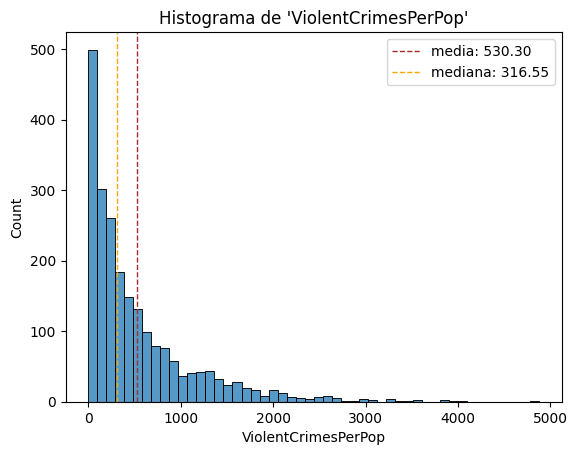

In [69]:
# creamos histograma de ViolentCrimesPerPop
hist = sns.histplot(data=df, x='ViolentCrimesPerPop', bins=50).set_title("Histograma de 'ViolentCrimesPerPop'")
plt.axvline(media, color='brown', linestyle='dashed', linewidth=1, label=f'media: {media:.2f}')
plt.axvline(mediana, color='orange', linestyle='dashed', linewidth=1, label=f'mediana: {mediana:.2f}')
plt.legend()

Procedemos a crear nuestro modelo lineal

In [70]:
# definimos variables target
target = df[['ViolentCrimesPerPop']].copy()

# definimos variables predictoras (quitando variables GOAL)
features = df.loc[:, ~df.columns.isin(['communityname','fold','state','murders','murdPerPop','rapes','rapesPerPop','robberies','robbbPerPop','assaults','assaultPerPop','burglaries','burglPerPop','larcenies','larcPerPop','autoTheft','autoTheftPerPop','arsons','arsonsPerPop','ViolentCrimesPerPop','nonViolPerPop',])].copy()

# dividimos en train y test
x_train, x_test, y_train, y_test = train_test_split(features, target, random_state=42, test_size=0.3)

In [71]:
# vemos la forma de cada split
print (x_train.shape, y_train.shape)
print (x_test.shape, y_test.shape)

(1550, 103) (1550, 1)
(665, 103) (665, 1)


Podemos notar que contamos con 1550 observaciones en la partición de entrenamiento y 665 en la de validación

In [72]:
# creamos el modelo lineal
model_1 = sm.OLS(y_train, x_train).fit()

In [73]:
print(model_1.summary())

                                 OLS Regression Results                                 
Dep. Variable:     ViolentCrimesPerPop   R-squared (uncentered):                   0.791
Model:                             OLS   Adj. R-squared (uncentered):              0.776
Method:                  Least Squares   F-statistic:                              54.26
Date:                 Mon, 10 Feb 2025   Prob (F-statistic):                        0.00
Time:                         18:46:39   Log-Likelihood:                         -11370.
No. Observations:                 1550   AIC:                                  2.294e+04
Df Residuals:                     1449   BIC:                                  2.348e+04
Df Model:                          101                                                  
Covariance Type:             nonrobust                                                  
                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------

In [74]:
# obtenemos la suma cuadrada de los residuos
model_1.ssr

213440893.08907363

Nuestro primer modelo obtiene un Coeficiente de Determinacion Ajustsado ($R^2_{ad}$) de **0.776**, lo cual indica que las variables independientes del modelo explican al rededor de un **77.6%** de la variabilidad de la variable dependiente `ViolentCrimesPerPop`. Mientras que obtuvimos una Suma Cuadrada de los Residuos ($SSR$) de **214293412**. También podemos notar un $AIC$ de **2.295e+04** y un $BIC$ de **2.348e+04**.

In [103]:
model_1.params.sort_values(ascending=False)

PersPerOwnOccHous     448.417850
PersPerOccupHous      338.160321
MalePctDivorce        128.931641
FemalePctDiv           72.580010
householdsize          72.555078
                         ...    
PctPersOwnOccup       -61.884222
PctRecentImmig        -64.319317
PersPerFam           -195.756431
TotalPctDiv          -198.736559
PersPerRentOccHous   -437.620280
Length: 103, dtype: float64

Notamos que las variables vinculadas a los nucleos habitacionales son las más influyentes al momento de determinar el índice de criminalidad de la comunidad

## Modelo lineal reducido

Para determinar cuales de las variable son significativas para nuestro modelo nos basaremos en el contraste de hipótesis, en nuestro caso, analizaremos los valores `p-values` que el modelo completo nos entrega, y definiendo un threshold de `0.05`, tomaremos solo aquellas variables predictoras que cumplan con la condición de significacia, a saber, diremos que para aquellas variables cuyo `p-value` sea mayor al umbral estipulado, no exisite evidencia suficiente para descartar la Hipotesis Nula ($H_0$), la cual indica que la variable no es significativa para el modelo y tiene un valor de coeficiente igual a 0.

In [75]:
# obtenemos aquellas variables predictoras con p-value menor al umbral
model_1.params[model_1.pvalues < 0.05]

agePct12t29              -37.494207
pctWInvInc                -6.862292
pctWPubAsst              -22.878824
AsianPerCap                0.002728
PctUnemployed            -20.640756
PctFam2Par                25.246708
PctKids2Par              -38.790586
PctKidsBornNeverMar       27.748546
PersPerRentOccHous      -437.620280
PctPersOwnOccup          -61.884222
PctHousOwnOcc             47.926882
PctVacantBoarded          21.424706
MedYrHousBuilt             2.128489
RentLowQ                  -0.637191
MedRent                    1.349875
MedRentPctHousInc        -12.942533
MedOwnCostPctIncNoMtg    -31.255418
LemasPctOfficDrugUn        7.310167
state_enc                 -2.358466
dtype: float64

Como podemos observar existen 18 variables significativas habiendo tomado un umbral de `0.05`. Utilizaremos todas estos predictores en nuestro modelo simplificado.

In [76]:
# creamos un dataframe auxiliar con las variables necesarias
df_aux = x_train.loc[:, x_train.columns.isin(['agePct12t29','medIncome','pctWInvInc','pctWPubAsst','AsianPerCap','PctUnemployed','PctEmplManu','PctFam2Par','PctKids2Par','PctKidsBornNeverMar','PersPerRentOccHous','PctPersOwnOccup','PctHousOwnOcc','PctVacantBoarded','MedYrHousBuilt','RentLowQ','MedRent','MedOwnCostPctIncNoMtg'])].copy()
df_aux["y"] = y_train.copy()

# creamos modelo con variables reducidas
model_2 = smf.ols(formula="y ~ agePct12t29 + medIncome + pctWInvInc + pctWPubAsst + AsianPerCap + PctUnemployed + PctEmplManu + PctFam2Par + PctKids2Par + PctKidsBornNeverMar + PersPerRentOccHous + PctPersOwnOccup + PctHousOwnOcc + PctVacantBoarded + MedYrHousBuilt + RentLowQ + MedRent + MedOwnCostPctIncNoMtg", data=df_aux) #decimos que y es una función de x
results_2 = model_2.fit() 

In [77]:
print(results_2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.586
Model:                            OLS   Adj. R-squared:                  0.582
Method:                 Least Squares   F-statistic:                     120.6
Date:                Mon, 10 Feb 2025   Prob (F-statistic):          1.38e-277
Time:                        18:46:40   Log-Likelihood:                -11461.
No. Observations:                1550   AIC:                         2.296e+04
Df Residuals:                    1531   BIC:                         2.306e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               232.95

In [78]:
# checkeamos Suma de los Residuos al Cuadrado
results_2.ssr

240127854.7780603

De acuerdo a lo esperado el nuevo modelo con menos variables predictoras posee un coeficiente $R^2_{ad}$ menor al modelo con todas las variables disponibles. En este caso obtuvimos un coeficiente de terminación ajustado de **0.582**. Además un $AIC$ de **2.296e+04**, levemente mayor que en el primer modelo, y un $BIC$ de **2.306e+04** ligeramente menor al anterior modelo. Debemos recordar que estas últimas dos métricas penalizan la inclusión de variables, con la intención de evitar un sobreajuste. 

En consonancia con lo anterior también notamos un aumento en la Suma de los Residuos al Cuadrado ($SSR$), obteniendo un valor de **240127854.77**.

In [102]:
results_2.params.sort_values(ascending=False)

Intercept                232.957465
PctKidsBornNeverMar       66.030939
PctFam2Par                48.778497
PersPerRentOccHous        26.647177
PctVacantBoarded          16.969123
MedYrHousBuilt             1.336529
PctHousOwnOcc              0.757064
MedRent                    0.662887
AsianPerCap                0.003140
medIncome                  0.000024
RentLowQ                  -0.765852
pctWInvInc                -5.716782
PctEmplManu               -8.292685
PctPersOwnOccup          -11.875081
PctUnemployed            -16.701709
pctWPubAsst              -16.882731
agePct12t29              -19.367098
MedOwnCostPctIncNoMtg    -34.848872
PctKids2Par              -56.682494
dtype: float64

Al igual que en el modelo anterior las variables de mayor peso al momento de analizar el indice de violencia de la comundiad resultan ser las vinculadas a las estructuras familiares, como ser `PctKidsBornNeverMar` (percentage of kids born to never married) o `PctFam2Par` (percentage of families (with kids) that are headed by two parents).

## Modelo polinomial

En primer lugar vamos a visualizar los histogramas de las variables que queremos analizar. Acompañando los histogramas anexamos las lines de tendencia correspondientes a la **tasa de crimenes violentos** en función de dichas variables


Index(['agePct12t29', 'medIncome', 'pctWInvInc', 'pctWPubAsst', 'AsianPerCap',
       'PctUnemployed', 'PctEmplManu', 'PctFam2Par', 'PctKids2Par',
       'PctKidsBornNeverMar', 'PersPerRentOccHous', 'PctPersOwnOccup',
       'PctHousOwnOcc', 'PctVacantBoarded', 'MedYrHousBuilt', 'RentLowQ',
       'MedRent', 'MedOwnCostPctIncNoMtg'],
      dtype='object')
axe 18


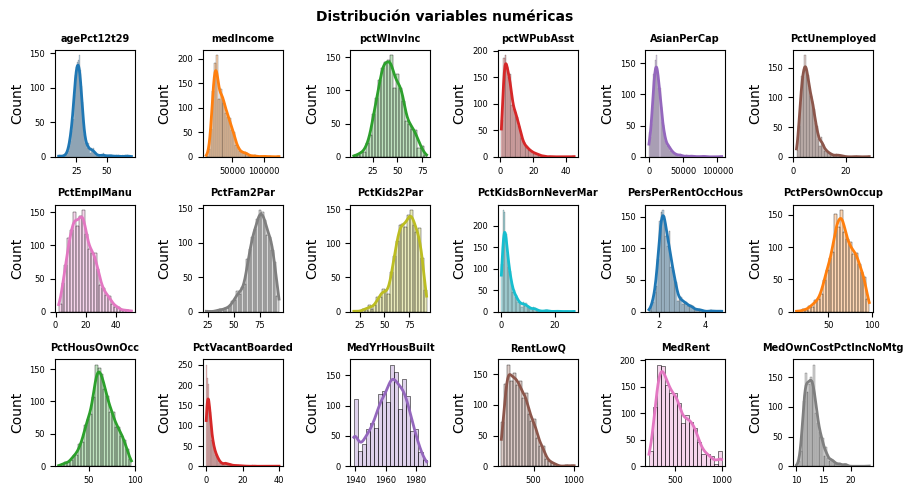

In [79]:
# Gráfico de distribución para cada variable numérica
# Ajustar número de subplots en función del número de columnas
fig, axes = plt.subplots(nrows=3, ncols=6, figsize=(9, 5))
axes = axes.flat
columnas_numeric = df_aux.select_dtypes(include=['float64', 'int']).columns
columnas_numeric = columnas_numeric.drop('y')

print(columnas_numeric)
print("axe", len(axes))

for i, colum in enumerate(columnas_numeric):
    sns.histplot(
        data    = df_aux,
        x       = colum,
        stat    = "count",
        kde     = True,
        color   = (list(plt.rcParams['axes.prop_cycle'])*2)[i]["color"],
        line_kws= {'linewidth': 2},
        alpha   = 0.3,
        ax      = axes[i]
    )
    axes[i].set_title(colum, fontsize = 7, fontweight = "bold")
    axes[i].tick_params(labelsize = 6)
    axes[i].set_xlabel("")
    
    
fig.tight_layout()
plt.subplots_adjust(top = 0.9)
fig.suptitle('Distribución variables numéricas', fontsize = 10, fontweight = "bold");


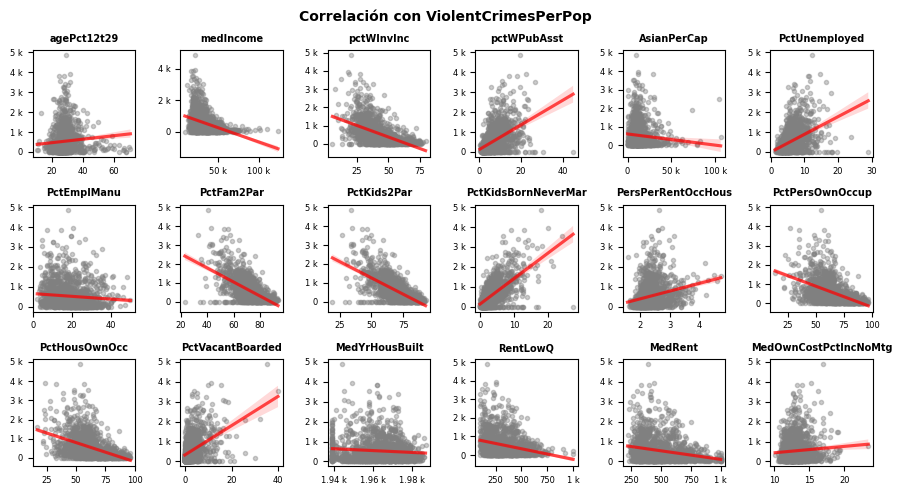

In [80]:
# graficamos la distribución para cada variable numérica
fig, axes = plt.subplots(nrows=3, ncols=6, figsize=(9, 5))
axes = axes.flat
columnas_numeric = df_aux.select_dtypes(include=['float64', 'int']).columns
columnas_numeric = columnas_numeric.drop('y')

import matplotlib.ticker as ticker

for i, colum in enumerate(columnas_numeric):
    sns.regplot(
        x           = df_aux[colum],
        y           = df_aux['y'],
        color       = "gray",
        marker      = '.',
        scatter_kws = {"alpha":0.4},
        line_kws    = {"color":"r","alpha":0.7},
        ax          = axes[i]
    )
    axes[i].set_title(f"{colum}", fontsize = 7, fontweight = "bold")
    #axes[i].ticklabel_format(style='sci', scilimits=(-4,4), axis='both')
    axes[i].yaxis.set_major_formatter(ticker.EngFormatter())
    axes[i].xaxis.set_major_formatter(ticker.EngFormatter())
    axes[i].tick_params(labelsize = 6)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

    
fig.tight_layout()
plt.subplots_adjust(top=0.9)
fig.suptitle('Correlación con ViolentCrimesPerPop', fontsize = 10, fontweight = "bold");

Podemos observar que dos variables que parecen guardar una relación no estrictamente lineal con tasa de címenes violentos, son los casos casos de `pctWPubAsst` y `PctUnemployed`. Existen tendencias crecientes en la tasa crímenes medida que aumentan ambas variables, a partir de cierto punto la tasa parece incrementarse drasticamente, probablemente sugiriendo una relación cuadrática entre las variables.

Incluiremos estos dos términos cuadráticos en nuestro modelo y analizaremos los resultados obtenidos.

In [81]:
# creamos var auxiliar
all_columns = '+'.join(df_aux.columns.difference(['y', 'pctWPubAsst', 'PctUnemployed']))
# creamos formula polinimica
formula = 'y ~ I(pctWPubAsst**2) + I(PctUnemployed**2) +' + all_columns

In [82]:
# definimos modelo lineal con formula polinomica
model_3 = smf.ols(formula = formula, data = df_aux)
results_3 = model_3.fit() #ajustamos el modelo

In [83]:
print(results_3.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.590
Method:                 Least Squares   F-statistic:                     125.1
Date:                Mon, 10 Feb 2025   Prob (F-statistic):          1.11e-284
Time:                        18:46:53   Log-Likelihood:                -11444.
No. Observations:                1550   AIC:                         2.293e+04
Df Residuals:                    1531   BIC:                         2.303e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept             -1560.03

In [84]:
# checkeamos Suma de los Residuos al Cuadrado
results_3.ssr

235022830.87208992

Con este ajuste polinómico notamos una mejora leve en la métrica de $R^2$ de nuestro modelo, pasando de un valor de **0.582** para el modelo lineal, a **0.590** para el modelo con variables cuadradas. Nuevamente AIC y BIC con valores muy similares a los dos modelos anteriores.

## Modelo Lineal Ponderado

In [86]:
import statsmodels.api as sm

# recreamos las particiones de train y test con las variables predictoras seleccionadas
x_train = x_train.loc[:, x_train.columns.isin(['agePct12t29','medIncome','pctWInvInc','pctWPubAsst','AsianPerCap','PctUnemployed','PctEmplManu','PctFam2Par','PctKids2Par','PctKidsBornNeverMar','PersPerRentOccHous','PctPersOwnOccup','PctHousOwnOcc','PctVacantBoarded','MedYrHousBuilt','RentLowQ','MedRent','MedOwnCostPctIncNoMtg'])].copy()
x_test = x_test.loc[:, x_test.columns.isin(['agePct12t29','medIncome','pctWInvInc','pctWPubAsst','AsianPerCap','PctUnemployed','PctEmplManu','PctFam2Par','PctKids2Par','PctKidsBornNeverMar','PersPerRentOccHous','PctPersOwnOccup','PctHousOwnOcc','PctVacantBoarded','MedYrHousBuilt','RentLowQ','MedRent','MedOwnCostPctIncNoMtg'])].copy()

# Calcular pesos inversamente proporcionales a la varianza de y_train
weights = 1 / (y_train + 1e-6)  # Se suma un pequeño valor para evitar divisiones por cero

# Agregar constante para el intercepto
x_train_w = sm.add_constant(x_train)
x_test_w = sm.add_constant(x_test)

# Ajustar el modelo de regresión ponderada
wls_model = sm.WLS(y_train, x_train_w, weights=weights)
wls_results = wls_model.fit()

print(wls_results.summary())

# Predicción en test
wls_pred = wls_results.predict(x_test_w)

wls_pred = wls_results.predict(x_test_w)


                             WLS Regression Results                            
Dep. Variable:     ViolentCrimesPerPop   R-squared:                       0.000
Model:                             WLS   Adj. R-squared:                 -0.012
Method:                  Least Squares   F-statistic:                 5.490e-06
Date:                 Mon, 10 Feb 2025   Prob (F-statistic):               1.00
Time:                         19:03:47   Log-Likelihood:                -10082.
No. Observations:                 1550   AIC:                         2.020e+04
Df Residuals:                     1531   BIC:                         2.030e+04
Df Model:                           18                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const               

## Model Ridge

In [85]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score


# Definimos el rango de alphas a probar en la regresión Ridge
alphas = [0.01, 0.1, 1, 10, 100]

ridge = RidgeCV(alphas=alphas, store_cv_values=True)
ridge.fit(x_train, y_train)

# Evaluamos con validación cruzada
ridge_scores = cross_val_score(ridge, x_train, y_train, cv=5, scoring='r2')

print(f"Mejor alpha para Ridge: {ridge.alpha_}")
print(f"R² medio en CV: {ridge_scores.mean()}")

# Predicción en test
ridge_pred = ridge.predict(x_test)
print(f"R² en test: {r2_score(y_test, ridge_pred)}")

Mejor alpha para Ridge: 100.0
R² medio en CV: 0.5635141303183533
R² en test: 0.5342187663663138


## Modelo Gradient Boosting

Para el modelo Gradient Boosting realizaremos un pequeño análisi para definir los hiperparámetros óptimos para el modelo

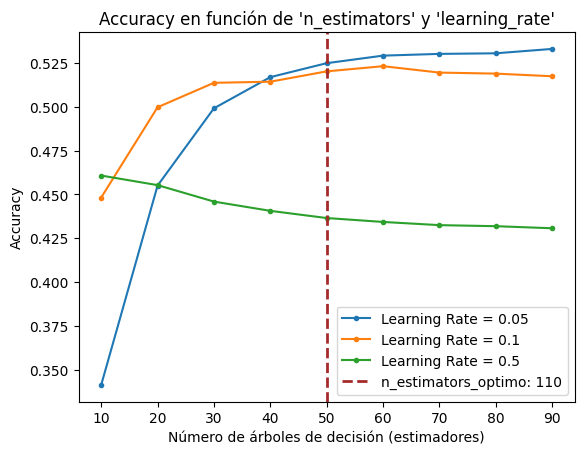

In [50]:
# definimos parámetros
min = 10
max = 100
hop = 10
max_depth = 5

# iteramos para encontrar los hiperparámetros adecuados
for learning_rate in [0.05, 0.1, 0.5]:
  accuracy = []
  mse_train_list = []
  mse_test_list = []

  for n_estimators in range (min, max, hop): 
    gb_model = GradientBoostingRegressor(random_state=0, n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate)
    gb_model.fit(x_train, y_train)

    accuracy.append(gb_model.score(x_test, y_test))
    # mse_train_list.append(mean_squared_error(y_train, pred_train))
    # mse_test_list.append(mean_squared_error(y_test, pred_test))

  plt.plot(range(min,max, hop), accuracy, marker='.', linestyle='-', label="Learning Rate = " + str(learning_rate))

plt.axvline(50, color='brown', linestyle='dashed', linewidth=2, label='n_estimators_optimo: 50')
plt.title("Accuracy en función de 'n_estimators' y 'learning_rate'")
plt.xlabel('Número de árboles de decisión (estimadores)')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

De lo anterior podemos decir que nuestro modelo óptimo tiene 50 `estimadores`, un `learning_rate` de 0.05 y un `max_depth` de 5

In [88]:
n_estimators = 50
max_depth = 5
learning_rate = 0.05

gb_model = GradientBoostingRegressor(random_state=0, n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate)
gb_model.fit(x_train, y_train)

pred_train = gb_model.predict(x_train)
pred_test = gb_model.predict(x_test)

print("Precisión sobre los datos de entrenamiento: {:.2f}".format(100.0*gb_model.score(x_train, y_train)))
print("Precisión sobre los datos de test: {:.2f}".format(100.0*gb_model.score(x_test, y_test)))

Precisión sobre los datos de entrenamiento: 82.14
Precisión sobre los datos de test: 52.48


## Modelo XGBoost

In [90]:
# creamos el modelo XGBoost
reg = XGBRegressor(
    tree_method="hist",
    eval_metric=mean_absolute_error,
)

reg.fit(x_train, y_train, eval_set=[(x_test, y_test)])

[0]	validation_0-rmse:520.52181	validation_0-mean_absolute_error:372.58633
[1]	validation_0-rmse:471.67114	validation_0-mean_absolute_error:330.66782
[2]	validation_0-rmse:441.45272	validation_0-mean_absolute_error:302.11871
[3]	validation_0-rmse:434.81889	validation_0-mean_absolute_error:290.91824
[4]	validation_0-rmse:427.87124	validation_0-mean_absolute_error:284.16598
[5]	validation_0-rmse:421.40983	validation_0-mean_absolute_error:276.92383
[6]	validation_0-rmse:421.72090	validation_0-mean_absolute_error:273.98618
[7]	validation_0-rmse:418.91873	validation_0-mean_absolute_error:271.53870
[8]	validation_0-rmse:417.71695	validation_0-mean_absolute_error:270.84418
[9]	validation_0-rmse:418.14610	validation_0-mean_absolute_error:270.01044
[10]	validation_0-rmse:420.62130	validation_0-mean_absolute_error:270.66602
[11]	validation_0-rmse:420.93274	validation_0-mean_absolute_error:270.95950
[12]	validation_0-rmse:419.24414	validation_0-mean_absolute_error:270.18716
[13]	validation_0-rmse

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False,
             eval_metric=<function mean_absolute_error at 0x3067c16c0>,
             feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [95]:
print(f"Precisión en entrenamiento: {reg.score(x_train, y_train)}")
print(f"Precisión en test: {reg.score(x_test, y_test)}")

Precisión en entrenamiento: 0.9992007613182068
Precisión en test: 0.49798476696014404


## Modelo de Regresión con LightGBM

In [97]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

lgb_reg = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=-1, random_state=42)
lgb_reg.fit(x_train, y_train)

# Predicción
lgb_pred = lgb_reg.predict(x_test)
r2_lgb = r2_score(y_test, lgb_pred)


# Evaluación
mse_lgb = mean_squared_error(y_test, lgb_pred)
print(f"MSE LightGBM: {mse_lgb}")
print(f"R² LightGBM: {r2_lgb}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004112 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4097
[LightGBM] [Info] Number of data points in the train set: 1550, number of used features: 18
[LightGBM] [Info] Start training from score 532.886943
MSE LightGBM: 167074.60581168372
R² LightGBM: 0.540355538275392


## Conclusiones

Durante el desarrollo de la actividad tuvimos la oportunidad de experimentar con diferentes modelos regresores, de los cuales el de mejor performance resultó ser el modelo lineal original con todas las variables predictoras. Este modelo obtuvo un $R^2$ de **0.79** indicando que es capaz de explicar el 79% de la variabilidad del problema. Lo siguientes modelos reducidos en dimensionalidad lograron desempeños un tanto mas pobres, debido a la pérdida de informacion inherente a la quita de variables independientes. En este sentido es necesario destacar que la complejidad computacional se ve reducida de manera directa con la performance de los modelos.

Dentro de los modelos de dimensionalidad redudica destacamos la performance del modelo polinómico, el obtuvo un $R^2_{ad}$ de **0.59**, cuyo desempeño supera a los demás por amplio margen. Para determinar cual es el modelo optimo se necesitaria definir el costo computacional maximo aceptado.

De análisis de regresión lineal inicial podemos notar que las variables que definien los nucleos familiares son las de mayor aporte al momento de tratar de modelar la tasa de criminalidad de la comunidad bajo estudio.
